# ROOT Fit：从数据、模型到参数与误差

拟合把测量数据与一个含未知参数的模型联系起来。例如，从标定点求出能量刻度系数，从能谱峰求出峰位、宽度与面积。曲线画得接近数据只是开始；还要知道采用了什么统计假设，参数误差如何得到，以及 residual 是否暴露出模型遗漏。

本教程先用测量点说明 weighted least squares，再拟合计数 histogram，最后处理 signal + background、协方差和 minimization。建议在学习第二章的参数估计后阅读；基本的 `TH1`、`TGraph` 与作图操作见 [ROOT Tutorial I](../tutorial/ROOT/ROOT_Tutorial_I_CPP.html)。

网页顶部可统一切换语言。下载的 notebook 使用 **Python 3 / PyROOT kernel**，从上到下运行；每段代码下可展开对应的 ROOT C++。图和打印结果由实际运行生成，C++ 完整宏在文末。所有数据均为明确给定参数的教学数据，不是探测器实测结果。

## 1. 数据的误差决定拟合方法

设模型为 $f(x;\boldsymbol p)$。对于独立测量点 $(x_i,y_i)$，若 $x_i$ 的误差可忽略，$y_i$ 的误差近似 Gaussian 且已知标准差 $s_i$，则

$$
L(\boldsymbol p)=\prod_i\frac{1}{\sqrt{2\pi}s_i}
\exp\left[-\frac{(y_i-f(x_i;\boldsymbol p))^2}{2s_i^2}\right].
$$

最大化 $L$ 等价于最小化

$$\chi^2=\sum_i\frac{[y_i-f(x_i;\boldsymbol p)]^2}{s_i^2}.$$

这就是 weighted least squares：误差小的点权重大。Likelihood 是固定数据后参数的函数，不是参数的概率密度。若测量点之间有相关误差，目标函数应写为 $\chi^2=\boldsymbol r^T V^{-1}\boldsymbol r$；普通 `TGraphErrors` 的独立误差条并不包含这个数据协方差矩阵 $V$。

| 数据 | 统计模型与入口 |
| --- | --- |
| 有已知、近似 Gaussian 误差的测量点 | `TGraphErrors::Fit`，weighted least squares |
| 未加权、未扣本底的计数 histogram | `TH1::Fit` 加 `L`，binned Poisson likelihood |
| 保留逐事件观测值 | unbinned likelihood；下一本教程用 RooFit 实现 |
| 同时估计事件总产额与分布形状 | extended likelihood；并非只能用于 unbinned 数据 |

### 1.1 准备 ROOT

后面的教学数据和随机样本可独立生成，不需要下载实验数据。固定随机种子便于重现。`SetBatch` 只控制图形窗口，不改变计算。

In [1]:
import math
from array import array
from pathlib import Path
from IPython.display import display, Image
import ROOT

ROOT.gROOT.SetBatch(True)
ROOT.gStyle.SetOptStat(0)
ROOT.gErrorIgnoreLevel = ROOT.kWarning  # 不打印图片保存提示，保留 warning/error
ROOT.Math.MinimizerOptions.SetDefaultMinimizer("Minuit2", "Migrad")
Path("fit_figures").mkdir(exist_ok=True)
print("ROOT", ROOT.gROOT.GetVersion())

ROOT 6.40.02


<details><summary>ROOT C++ 对应代码</summary>

```cpp
gROOT->SetBatch(true);
gStyle->SetOptStat(0);
gErrorIgnoreLevel = kWarning;  // 不打印图片保存提示，保留 warning/error
ROOT::Math::MinimizerOptions::SetDefaultMinimizer("Minuit2", "Migrad");
gSystem->mkdir("fit_figures", true);
std::cout << std::fixed << std::setprecision(4);
std::cout << "ROOT " << gROOT->GetVersion() << std::endl;
```

</details>

### 1.2 拟合一组标定点

用 $y=a+b x$ 描述下列标定点。这里 $x$ 是已知的输入量，$y$ 是仪器的响应；数值以任意单位给出。`pol1` 表示一次多项式，参数 `[0]` 是截距，`[1]` 是斜率。

`S` 让 `Fit` 返回完整的 `TFitResult`；`Q` 关闭自动打印，便于只输出关心的结果；`0` 不自动绘图，随后显式绘制。`TGraphErrors` 已经给出了误差，不要加 `W`，它会忽略这些误差。

In [2]:
x = array("d", [0, 2, 4, 6, 8, 10])
y = array("d", [5, 8, 14, 20, 24, 35])
ex = array("d", [0] * 6)
ey = array("d", [2, 1.5, 2.5, 1, 3, 2])
graph = ROOT.TGraphErrors(6, x, y, ex, ey)
line = ROOT.TF1("line", "pol1", 0, 10)
line.SetParNames("a", "b")
line_result = graph.Fit(line, "SQ0")
print("status =", int(line_result))
for j in range(2):
    print(f"{line.GetParName(j)} = {line.GetParameter(j):.4f} +/- {line.GetParError(j):.4f}")
print(f"chi2 / ndf = {line_result.Chi2():.3f} / {line_result.Ndf()}")

status = 0
a = 2.7285 +/- 1.3242
b = 2.9692 +/- 0.2316
chi2 / ndf = 4.190 / 4


<details><summary>ROOT C++ 对应代码</summary>

```cpp
double x[] = {0, 2, 4, 6, 8, 10};
double y[] = {5, 8, 14, 20, 24, 35};
double ex[] = {0, 0, 0, 0, 0, 0};
double ey[] = {2, 1.5, 2.5, 1, 3, 2};
auto graph = new TGraphErrors(6, x, y, ex, ey);
auto line = new TF1("line", "pol1", 0, 10);
line->SetParNames("a", "b");
TFitResultPtr line_result = graph->Fit(line, "SQ0");
std::cout << "status = " << int(line_result) << std::endl;
for (int j = 0; j < 2; ++j)
    std::cout << line->GetParName(j) << " = " << line->GetParameter(j)
              << " +/- " << line->GetParError(j) << std::endl;
std::cout << "chi2 / ndf = " << line_result->Chi2() << " / " << line_result->Ndf() << std::endl;
```

</details>

### 1.3 拟合曲线与 residual

Residual 定义为 $r_i=y_i-f(x_i)$。下面保留原测量误差条，使偏离的大小有参照。若 residual 连续偏向同一侧或有弯曲趋势，需要检查线性模型，而不只是看一个 $\chi^2/\mathrm{ndf}$ 数值。

在线性模型、独立 Gaussian 误差已知等假设下，最小 $\chi^2$ 服从自由度 $N-p$ 的 $\chi^2$ 分布。非线性模型中通常只是近似；“接近 1”不是普遍的验收标准。

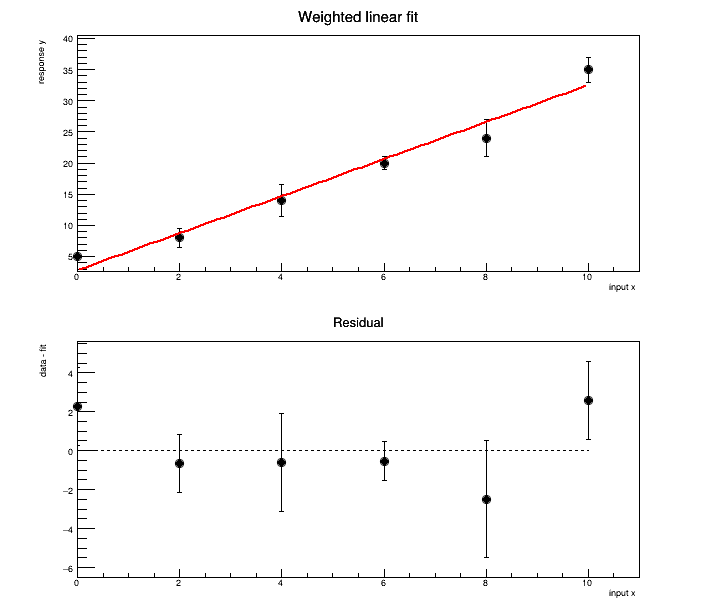

In [3]:
residual = ROOT.TGraphErrors(6)
for i in range(6):
    residual.SetPoint(i, x[i], y[i] - line.Eval(x[i]))
    residual.SetPointError(i, 0, ey[i])
c = ROOT.TCanvas("c_line", "Weighted fit and residual", 720, 640)
c.Divide(1, 2)
c.cd(1)
graph.SetTitle("Weighted linear fit;input x;response y")
graph.SetMarkerStyle(20)
graph.Draw("AP")
line.Draw("same")
c.cd(2)
residual.SetTitle("Residual;input x;data - fit")
residual.SetMarkerStyle(20)
residual.Draw("AP")
zero_line = ROOT.TLine(0, 0, 10, 0)
zero_line.SetLineStyle(2)
zero_line.Draw()
c.SaveAs("fit_figures/root-weighted-fit.png")
display(Image(filename="fit_figures/root-weighted-fit.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
auto residual = new TGraphErrors(6);
for (int i = 0; i < 6; ++i) {
    residual->SetPoint(i, x[i], y[i] - line->Eval(x[i]));
    residual->SetPointError(i, 0, ey[i]);
}
auto c = new TCanvas("c_line", "Weighted fit and residual", 720, 640);
c->Divide(1, 2);
c->cd(1);
graph->SetTitle("Weighted linear fit;input x;response y");
graph->SetMarkerStyle(20);
graph->Draw("AP");
line->Draw("same");
c->cd(2);
residual->SetTitle("Residual;input x;data - fit");
residual->SetMarkerStyle(20);
residual->Draw("AP");
auto zero_line = new TLine(0, 0, 10, 0);
zero_line->SetLineStyle(2);
zero_line->Draw();
c->SaveAs("fit_figures/root-weighted-fit.png");
```

</details>

<a id="weighted-uncertainty"></a>
### 1.4 从参数误差到拟合值误差

拟合给出的参数协方差矩阵记为 $C$。它不同于前面测量数据的协方差矩阵 $V$。对于 $g(\boldsymbol p)$，一阶误差传播为

$$\sigma_g^2=\sum_{j,k}\frac{\partial g}{\partial p_j}C_{jk}\frac{\partial g}{\partial p_k}.$$

例如，在给定 $x_0$ 处，$g=a+bx_0$，因此

$$\sigma_g^2=C_{aa}+2x_0C_{ab}+x_0^2 C_{bb}.$$

截距和斜率由同一批数据决定，通常有相关性。只保留两项平方误差会漏掉交叉项。下面的带表示拟合均值的一阶 $\pm1\sigma$ 不确定度，不是下一次测量的 prediction band；后者还要考虑新测量自身的涨落。

f(5.0) = 17.5745 +/- 0.6720
corr(a,b) = -0.8617


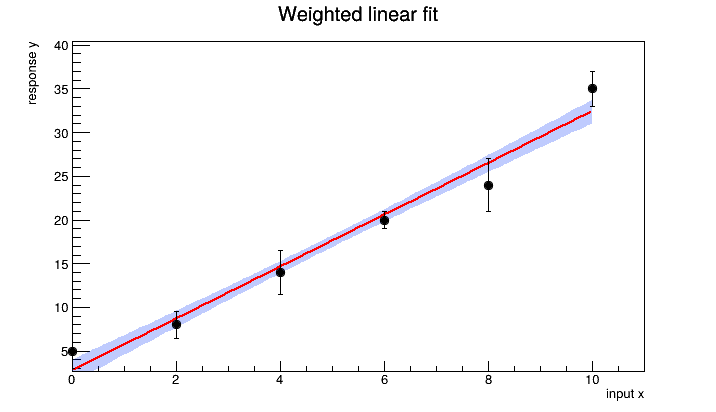

In [4]:
C = line_result.GetCovarianceMatrix()
x0 = 5.0
variance = C[0][0] + 2*x0*C[0][1] + x0*x0*C[1][1]
print(f"f({x0}) = {line.Eval(x0):.4f} +/- {math.sqrt(variance):.4f}")
print(f"corr(a,b) = {line_result.Correlation(0,1):.4f}")
band = ROOT.TGraphErrors(101)
for i in range(101):
    xx = i / 10
    vv = C[0][0] + 2*xx*C[0][1] + xx*xx*C[1][1]
    band.SetPoint(i, xx, line.Eval(xx))
    band.SetPointError(i, 0, math.sqrt(vv))
c = ROOT.TCanvas("c_band", "Fitted mean uncertainty", 720, 440)
graph.Draw("AP")
band.SetFillColorAlpha(ROOT.kAzure, 0.25)
band.Draw("3 same")
line.Draw("same")
graph.Draw("P same")
c.SaveAs("fit_figures/root-fit-band.png")
display(Image(filename="fit_figures/root-fit-band.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
TMatrixDSym C = line_result->GetCovarianceMatrix();
double x0 = 5.0;
double variance = C(0,0) + 2*x0*C(0,1) + x0*x0*C(1,1);
std::cout << "f(5) = " << line->Eval(x0) << " +/- " << std::sqrt(variance) << std::endl;
std::cout << "corr(a,b) = " << line_result->Correlation(0,1) << std::endl;
auto band = new TGraphErrors(101);
for (int i = 0; i <= 100; ++i) {
    double xx = i / 10.0;
    double vv = C(0,0) + 2*xx*C(0,1) + xx*xx*C(1,1);
    band->SetPoint(i, xx, line->Eval(xx));
    band->SetPointError(i, 0, std::sqrt(vv));
}
c = new TCanvas("c_band", "Fitted mean uncertainty", 720, 440);
graph->Draw("AP");
band->SetFillColorAlpha(kAzure, 0.25);
band->Draw("3 same");
line->Draw("same");
graph->Draw("P same");
c->SaveAs("fit_figures/root-fit-band.png");
```

</details>

## 2. 用 TF1 拟合 Gaussian 峰

`TF1` 表示一维含参数函数。`gaus` 对应

$$f(x)=A\exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right].$$

三个参数依次为 $A,\mu,\sigma$；这里 $A$ 是峰高，不是面积。`gaus(0)+pol1(3)` 表示把 Gaussian 的三个参数放在 `[0:2]`，线性本底的两个参数放在 `[3:4]`。`expo` 则是 $\exp(p_0+p_1x)$，不是 $p_0\exp(-x/p_1)$。衰减时 $p_1<0$，衰减常数为 $-p_1$，寿命为 $-1/p_1$。

### 2.1 从同一个样本建立 histogram

下面抽取 1000 个 Gaussian 随机数，生成参数为 $\mu=0.4$、$\sigma=0.7$。样本量固定，只用来检验峰形参数的提取。

status = 0 covariance status = 3
mean = 0.4228 +/- 0.0222
sigma = 0.7002 +/- 0.0157


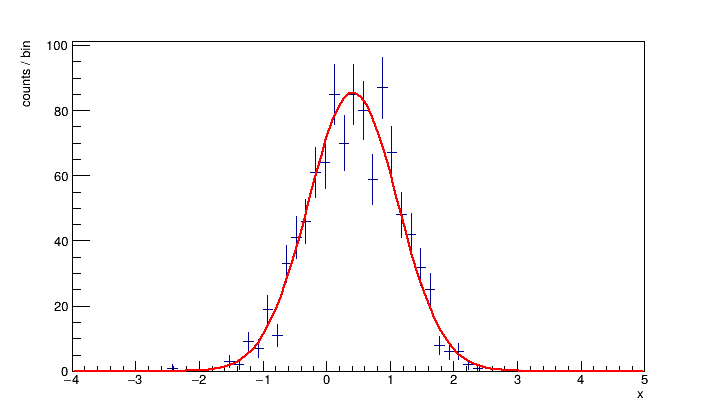

In [5]:
rng = ROOT.TRandom3(20260910)
h = ROOT.TH1D("h_gauss", ";x;counts / bin", 60, -4, 5)
for i in range(1000):
    h.Fill(rng.Gaus(0.4, 0.7))
f = ROOT.TF1("f_gauss", "gaus", -4, 5)
f.SetParameters(h.GetMaximum(), h.GetMean(), h.GetStdDev())
f.SetParLimits(2, 0.1, 3.0)  # sigma 必须为正
fit = h.Fit(f, "LIRS0Q")
print("status =", int(fit), "covariance status =", fit.CovMatrixStatus())
print(f"mean = {f.GetParameter(1):.4f} +/- {f.GetParError(1):.4f}")
print(f"sigma = {f.GetParameter(2):.4f} +/- {f.GetParError(2):.4f}")
c = ROOT.TCanvas("c_gauss", "Gaussian fit", 720, 440)
h.Draw("E")
f.Draw("same")
c.SaveAs("fit_figures/root-gaussian.png")
display(Image(filename="fit_figures/root-gaussian.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
TRandom3 rng(20260910);
auto h = new TH1D("h_gauss", ";x;counts / bin", 60, -4, 5);
for (int i = 0; i < 1000; ++i) h->Fill(rng.Gaus(0.4, 0.7));
auto f = new TF1("f_gauss", "gaus", -4, 5);
f->SetParameters(h->GetMaximum(), h->GetMean(), h->GetStdDev());
f->SetParLimits(2, 0.1, 3.0);  // sigma 必须为正
TFitResultPtr fit = h->Fit(f, "LIRS0Q");
std::cout << "status = " << int(fit) << " covariance status = " << fit->CovMatrixStatus() << std::endl;
std::cout << "mean = " << f->GetParameter(1) << " +/- " << f->GetParError(1) << std::endl;
std::cout << "sigma = " << f->GetParameter(2) << " +/- " << f->GetParError(2) << std::endl;
c = new TCanvas("c_gauss", "Gaussian fit", 720, 440);
h->Draw("E");
f->Draw("same");
c->SaveAs("fit_figures/root-gaussian.png");
```

</details>

### 2.2 逐项理解 Fit 的选项

上面 `LIRS0Q` 的字符可组合使用，顺序不重要。

| 选项 | 在这个例子中的作用 |
| --- | --- |
| `L` | 以每个 bin 的 Poisson 计数建立 likelihood，而不是默认的 $\chi^2$ |
| `I` | 用函数在 bin 内的平均值：积分除以 bin 宽度，而不只取 bin 中心的函数值 |
| `R` | 使用 `TF1` 定义的拟合范围 |
| `S` | 保存完整的参数、协方差与拟合状态 |
| `0` | 不自动画拟合结果；函数仍保存在 histogram 中 |
| `Q` | 关闭自动报告；上面主动打印了参数与状态 |

`SetParameters` 给初值，`SetParameter(j,value)` 改一个初值，`SetParLimits` 给参数允许范围，`FixParameter` 才是固定参数不参与拟合。初值帮助 minimizer 找到合理区域，不是预先指定答案。Gaussian 单峰常可由 histogram 自动估计初值；混合峰与本底时不能依赖这种自动估计。

`I` 的归一化尤其容易弄错。对**等宽、纵轴为 counts/bin 的 histogram**，上述 `f` 的量纲仍是 counts/bin。若要从曲线积分得到事例数，需要再除以 bin 宽度。若使用不同宽度的 bins，不能沿用一个固定宽度来换算。[TH1::Fit 官方说明](https://root.cern.ch/doc/master/classTH1.html)给出了这些选项的定义。

## 3. 少计数 histogram：Poisson likelihood 与 least squares

计数 histogram 的模型是 $n_i\sim\operatorname{Poisson}(\mu_i)$，其中 $\mu_i$ 是**预测的 bin 计数**。其负对数 likelihood 去掉参数无关项后为

$$-\log L=\sum_i[\mu_i-n_i\log\mu_i].$$

默认的 histogram least squares 常用 $\sqrt{n_i}$ 作为误差，空 bin 的误差为零，因此不参与这个默认拟合。Poisson likelihood 中空 bin 仍提供约束：该处的预测计数不能任意增大。这里讨论的是原始计数；本底扣除后有负值的 histogram、归一化分布与带权事件不能直接套用这个模型。

使用同一个指数衰减样本比较两种拟合。$\tau=1$ s，50 个事件，保留 $[0,8]$ s 的 histogram；末尾同时输出范围外的事件数。两条曲线的差异只是一次有限样本的结果，不能由一张图量化方法的系统偏差。

In [6]:
h_decay = ROOT.TH1D("h_decay", ";t (s);counts / bin", 32, 0, 8)
for i in range(50):
    h_decay.Fill(rng.Exp(1.0))
f_poisson = ROOT.TF1("f_poisson", "[0]*exp(-x/[1])", 0, 8)
f_ls = ROOT.TF1("f_ls", "[0]*exp(-x/[1])", 0, 8)
for fun in (f_poisson, f_ls):
    fun.SetParameters(12, 1)
    fun.SetParLimits(0, 0.01, 1000)
    fun.SetParLimits(1, 0.1, 5)
r_poisson = h_decay.Fit(f_poisson, "LIRS0Q")
r_ls = h_decay.Fit(f_ls, "IRS0Q")
print("outside range =", h_decay.GetBinContent(33))
print(f"Poisson: tau = {f_poisson.GetParameter(1):.4f} +/- {f_poisson.GetParError(1):.4f}; status {int(r_poisson)}")
print(f"LS:      tau = {f_ls.GetParameter(1):.4f} +/- {f_ls.GetParError(1):.4f}; status {int(r_ls)}")

outside range = 0.0
Poisson: tau = 1.0901 +/- 0.1571; status 0
LS:      tau = 1.1515 +/- 0.4007; status 0


<details><summary>ROOT C++ 对应代码</summary>

```cpp
auto h_decay = new TH1D("h_decay", ";t (s);counts / bin", 32, 0, 8);
for (int i = 0; i < 50; ++i) h_decay->Fill(rng.Exp(1.0));
auto f_poisson = new TF1("f_poisson", "[0]*exp(-x/[1])", 0, 8);
auto f_ls = new TF1("f_ls", "[0]*exp(-x/[1])", 0, 8);
for (auto fun : {f_poisson, f_ls}) {
    fun->SetParameters(12, 1);
    fun->SetParLimits(0, 0.01, 1000);
    fun->SetParLimits(1, 0.1, 5);
}
TFitResultPtr r_poisson = h_decay->Fit(f_poisson, "LIRS0Q");
TFitResultPtr r_ls = h_decay->Fit(f_ls, "IRS0Q");
std::cout << "outside range = " << h_decay->GetBinContent(33) << std::endl;
std::cout << "Poisson: tau = " << f_poisson->GetParameter(1) << " +/- " << f_poisson->GetParError(1) << "; status " << int(r_poisson) << std::endl;
std::cout << "LS:      tau = " << f_ls->GetParameter(1) << " +/- " << f_ls->GetParError(1) << "; status " << int(r_ls) << std::endl;
```

</details>

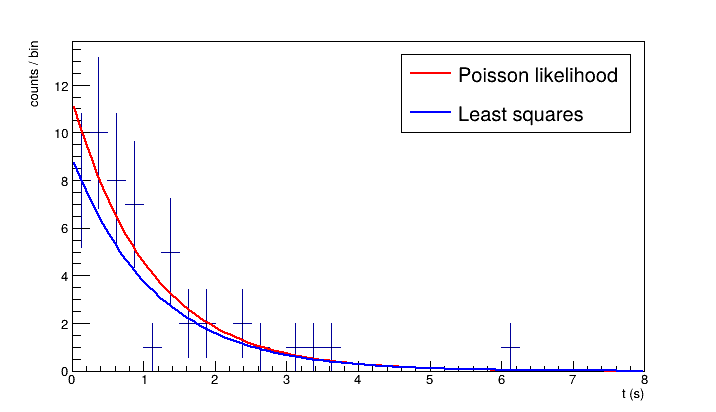

In [7]:
c = ROOT.TCanvas("c_decay", "Sparse counts", 720, 440)
h_decay.Draw("E")
f_poisson.SetLineColor(ROOT.kRed)
f_ls.SetLineColor(ROOT.kBlue)
f_poisson.Draw("same")
f_ls.Draw("same")
legend = ROOT.TLegend(0.56, 0.68, 0.88, 0.87)
legend.AddEntry(f_poisson, "Poisson likelihood", "l")
legend.AddEntry(f_ls, "Least squares", "l")
legend.Draw()
c.SaveAs("fit_figures/root-sparse-counts.png")
display(Image(filename="fit_figures/root-sparse-counts.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
c = new TCanvas("c_decay", "Sparse counts", 720, 440);
h_decay->Draw("E");
f_poisson->SetLineColor(kRed);
f_ls->SetLineColor(kBlue);
f_poisson->Draw("same");
f_ls->Draw("same");
auto legend = new TLegend(0.56, 0.68, 0.88, 0.87);
legend->AddEntry(f_poisson, "Poisson likelihood", "l");
legend->AddEntry(f_ls, "Least squares", "l");
legend->Draw();
c->SaveAs("fit_figures/root-sparse-counts.png");
```

</details>

计数较高时两种方法常更接近，因为 Poisson 分布逐渐接近 Gaussian，但尾部仍可能是少计数。更多事件不会自动修正错误的峰形或本底模型。逐事件的衰变时间拟合及有限观察范围的归一化见 [RooFit 教程第 7 节](RooFit%20mini%20tutorial.html#decay)。

## 4. Signal + background：从初值到联合拟合

在一个窄能量区间内，先以 Gaussian 描述峰、线性函数描述局部连续本底：

$$f(E)=A\exp[-(E-\mu)^2/(2\sigma^2)]+b_0+b_1(E-50).$$

把本底写在区间中心附近，可以减少常数项与斜率之间因坐标零点过远产生的相关性。线性只是局部近似：若 residual 显示结构，再根据能谱特征考虑阶跃、尾部或相邻峰；并不是给本底增加参数就一定更可靠。

### 4.1 建立可检验的教学能谱

假设 $A=70$ counts/bin、$\mu=50$ keV、$\sigma=1.2$ keV、$b_0=20$ counts/bin、$b_1=-0.5$ counts/bin/keV。每个 bin 的计数独立服从 Poisson 分布，均值由模型在该 bin 的积分确定。这样区分了模型真值和有限统计量的拟合结果。

Observed counts = 3081


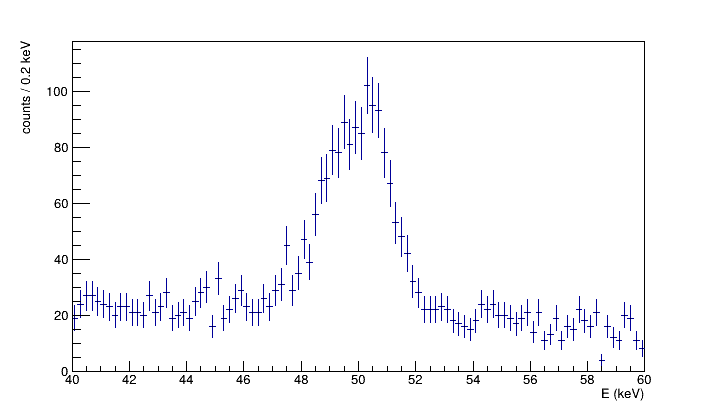

In [8]:
hp = ROOT.TH1D("hp", ";E (keV);counts / 0.2 keV", 100, 40, 60)
truth = ROOT.TF1("truth", "gaus(0)+[3]+[4]*(x-50)", 40, 60)
truth.SetParameters(70, 50, 1.2, 20, -0.5)
width = hp.GetBinWidth(1)
for i in range(1, 101):
    lo = hp.GetBinLowEdge(i)
    expected = truth.Integral(lo, lo + width) / width
    hp.SetBinContent(i, rng.Poisson(expected))
c = ROOT.TCanvas("c_spectrum", "Teaching spectrum", 720, 440)
hp.Draw("E")
print("Observed counts =", int(hp.Integral()))
c.SaveAs("fit_figures/root-spectrum.png")
display(Image(filename="fit_figures/root-spectrum.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
auto hp = new TH1D("hp", ";E (keV);counts / 0.2 keV", 100, 40, 60);
auto truth = new TF1("truth", "gaus(0)+[3]+[4]*(x-50)", 40, 60);
truth->SetParameters(70, 50, 1.2, 20, -0.5);
double width = hp->GetBinWidth(1);
for (int i = 1; i <= 100; ++i) {
    double lo = hp->GetBinLowEdge(i);
    double expected = truth->Integral(lo, lo + width) / width;
    hp->SetBinContent(i, rng.Poisson(expected));
}
c = new TCanvas("c_spectrum", "Teaching spectrum", 720, 440);
hp->Draw("E");
std::cout << "Observed counts = " << hp->Integral() << std::endl;
c->SaveAs("fit_figures/root-spectrum.png");
```

</details>

### 4.2 用两侧 sidebands 估计本底初值

从峰两侧 $[40,46]$ 与 $[54,60]$ keV 的 bins 建立 graph，先拟合直线。本例 sidebands 中 Gaussian 的贡献很小。这里的 least-squares 预拟合**只提供初值**，不把本底误差固定下来；最后会对峰与两侧本底的全部计数一起进行 Poisson likelihood fit。

Background initial values: b0 = 18.810, b1 = -0.611


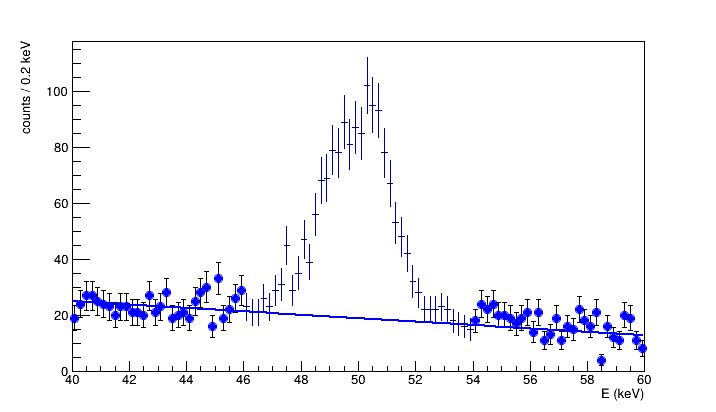

In [9]:
side = ROOT.TGraphErrors()
for i in range(1, 101):
    energy = hp.GetBinCenter(i)
    count = hp.GetBinContent(i)
    if energy < 46 or energy > 54:
        k = side.GetN()
        side.SetPoint(k, energy, count)
        side.SetPointError(k, 0, math.sqrt(max(count, 1)))
bg_seed = ROOT.TF1("bg_seed", "[0]+[1]*(x-50)", 40, 60)
side_result = side.Fit(bg_seed, "SQ0")
print(f"Background initial values: b0 = {bg_seed.GetParameter(0):.3f}, b1 = {bg_seed.GetParameter(1):.3f}")
c = ROOT.TCanvas("c_side", "Sideband estimate", 720, 440)
hp.Draw("E")
side.SetMarkerStyle(20)
side.SetMarkerColor(ROOT.kBlue)
side.Draw("P same")
bg_seed.SetLineColor(ROOT.kBlue)
bg_seed.Draw("same")
c.SaveAs("fit_figures/root-sidebands.png")
display(Image(filename="fit_figures/root-sidebands.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
auto side = new TGraphErrors();
for (int i = 1; i <= 100; ++i) {
    double energy = hp->GetBinCenter(i), count = hp->GetBinContent(i);
    if (energy < 46 || energy > 54) {
        int k = side->GetN();
        side->SetPoint(k, energy, count);
        side->SetPointError(k, 0, std::sqrt(std::max(count, 1.0)));
    }
}
auto bg_seed = new TF1("bg_seed", "[0]+[1]*(x-50)", 40, 60);
TFitResultPtr side_result = side->Fit(bg_seed, "SQ0");
std::cout << "Background initial values: b0 = " << bg_seed->GetParameter(0)
          << ", b1 = " << bg_seed->GetParameter(1) << std::endl;
c = new TCanvas("c_side", "Sideband estimate", 720, 440);
hp->Draw("E");
side->SetMarkerStyle(20);
side->SetMarkerColor(kBlue);
side->Draw("P same");
bg_seed->SetLineColor(kBlue);
bg_seed->Draw("same");
c->SaveAs("fit_figures/root-sidebands.png");
```

</details>

### 4.3 拟合整个区间，并画出完整模型与分量

峰高初值来自能谱最大值减去本底，峰位由最大值所在位置估计，宽度给一个与图中峰宽相近的数。下列边界覆盖本教学模型的合理参数区域，并保证全区间本底为正。实际分析应根据数据与仪器知识选取，不能用窄边界强迫拟合得到预期结果。

In [10]:
model = ROOT.TF1("peak_background", "gaus(0)+[3]+[4]*(x-50)", 40, 60)
model.SetParNames("A", "mean", "sigma", "b0", "b1")
model.SetParameters(hp.GetMaximum()-bg_seed.Eval(50),
                    hp.GetBinCenter(hp.GetMaximumBin()), 1,
                    bg_seed.GetParameter(0), bg_seed.GetParameter(1))
model.SetParLimits(0, 1, 1000)
model.SetParLimits(1, 46, 54)
model.SetParLimits(2, 0.2, 3)
model.SetParLimits(3, 10, 100)
model.SetParLimits(4, -0.9, 0.9)
peak_result = hp.Fit(model, "LIRS0Q")
print("status =", int(peak_result), "covariance status =", peak_result.CovMatrixStatus())
for j in range(5):
    print(f"{model.GetParName(j):5s} = {model.GetParameter(j):.4f} +/- {model.GetParError(j):.4f}")

status = 0 covariance status = 3
A     = 74.3831 +/- 3.4555
mean  = 49.9293 +/- 0.0517
sigma = 1.1580 +/- 0.0496
b0    = 20.0148 +/- 0.5475
b1    = -0.5269 +/- 0.0794


<details><summary>ROOT C++ 对应代码</summary>

```cpp
auto model = new TF1("peak_background", "gaus(0)+[3]+[4]*(x-50)", 40, 60);
model->SetParNames("A", "mean", "sigma", "b0", "b1");
model->SetParameters(hp->GetMaximum()-bg_seed->Eval(50),
                     hp->GetBinCenter(hp->GetMaximumBin()), 1,
                     bg_seed->GetParameter(0), bg_seed->GetParameter(1));
model->SetParLimits(0, 1, 1000);
model->SetParLimits(1, 46, 54);
model->SetParLimits(2, 0.2, 3);
model->SetParLimits(3, 10, 100);
model->SetParLimits(4, -0.9, 0.9);
TFitResultPtr peak_result = hp->Fit(model, "LIRS0Q");
std::cout << "status = " << int(peak_result) << " covariance status = " << peak_result->CovMatrixStatus() << std::endl;
for (int j = 0; j < 5; ++j)
    std::cout << model->GetParName(j) << " = " << model->GetParameter(j)
              << " +/- " << model->GetParError(j) << std::endl;
```

</details>

联合拟合后的本底不必与 sideband 预拟合完全相同，因为峰区数据也参与约束本底。图中红线为总模型，蓝虚线为本底，绿线为 Gaussian 分量；它们都取自同一次联合拟合。

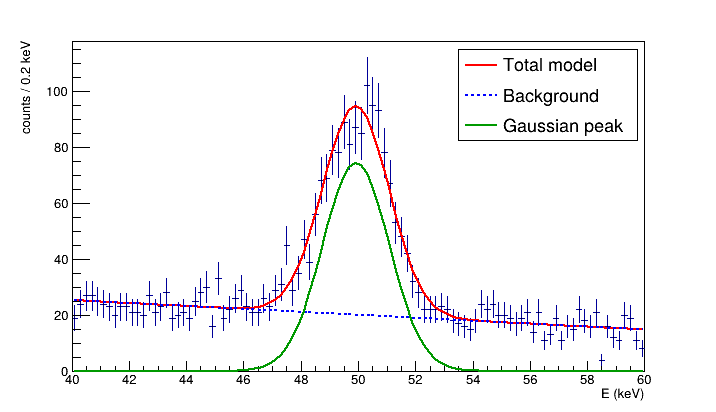

In [11]:
signal = ROOT.TF1("signal", "gaus", 40, 60)
signal.SetParameters(model.GetParameter(0), model.GetParameter(1), model.GetParameter(2))
background = ROOT.TF1("background", "[0]+[1]*(x-50)", 40, 60)
background.SetParameters(model.GetParameter(3), model.GetParameter(4))
c = ROOT.TCanvas("c_peak", "Peak plus background", 720, 440)
hp.Draw("E")
model.SetLineColor(ROOT.kRed)
background.SetLineColor(ROOT.kBlue)
background.SetLineStyle(2)
signal.SetLineColor(ROOT.kGreen+2)
model.Draw("same")
background.Draw("same")
signal.Draw("same")
peak_legend = ROOT.TLegend(0.64, 0.66, 0.89, 0.88)
peak_legend.AddEntry(model, "Total model", "l")
peak_legend.AddEntry(background, "Background", "l")
peak_legend.AddEntry(signal, "Gaussian peak", "l")
peak_legend.Draw()
c.SaveAs("fit_figures/root-peak-background.png")
display(Image(filename="fit_figures/root-peak-background.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
auto signal = new TF1("signal", "gaus", 40, 60);
signal->SetParameters(model->GetParameter(0), model->GetParameter(1), model->GetParameter(2));
auto background = new TF1("background", "[0]+[1]*(x-50)", 40, 60);
background->SetParameters(model->GetParameter(3), model->GetParameter(4));
c = new TCanvas("c_peak", "Peak plus background", 720, 440);
hp->Draw("E");
model->SetLineColor(kRed);
background->SetLineColor(kBlue);
background->SetLineStyle(2);
signal->SetLineColor(kGreen+2);
model->Draw("same");
background->Draw("same");
signal->Draw("same");
auto peak_legend = new TLegend(0.64, 0.66, 0.89, 0.88);
peak_legend->AddEntry(model, "Total model", "l");
peak_legend->AddEntry(background, "Background", "l");
peak_legend->AddEntry(signal, "Gaussian peak", "l");
peak_legend->Draw();
c->SaveAs("fit_figures/root-peak-background.png");
```

</details>

### 4.4 用同一 bin 模型计算 residual

因为拟合用了 `I`，诊断时也用 $\mu_i=\int_i f(E)dE/\Delta E$。下图画 Pearson residual $(n_i-\mu_i)/\sqrt{\mu_i}$，空 bin 也能计算。它用于观察结构，不应把每个点机械地当成独立标准正态变量，尤其在少计数时。

还可计算 Poisson deviance（Baker–Cousins statistic）：

$$D=2\sum_i\left[\mu_i-n_i+n_i\ln\frac{n_i}{\mu_i}\right],$$

$n_i=0$ 时最后一项取零。它比较当前模型与每个 bin 都能独立调整均值的 saturated model。大样本正则条件下可近似与 $\chi^2_{N_\mathrm{bins}-p}$ 比较；稀疏数据或参数边界附近的 goodness-of-fit 更适合用 toy experiments 标定，不能无条件套用渐近 p-value。

Poisson deviance = 86.440; bins - parameters = 95


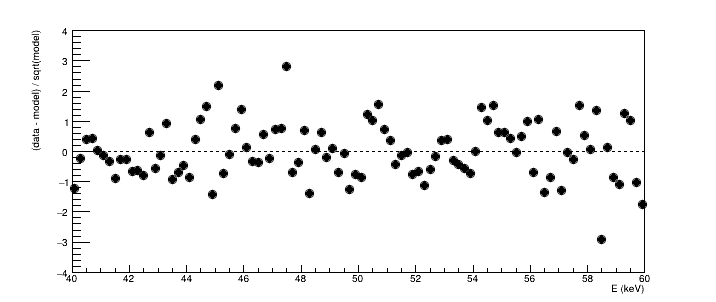

In [12]:
pull = ROOT.TH1D("peak_pull", ";E (keV);(data - model) / sqrt(model)", 100, 40, 60)
deviance = 0.0
for i in range(1, 101):
    lo = hp.GetBinLowEdge(i)
    mu_i = model.Integral(lo, lo+width) / width
    ni = hp.GetBinContent(i)
    pull.SetBinContent(i, (ni-mu_i)/math.sqrt(mu_i))
    deviance += 2*(mu_i-ni + (ni*math.log(ni/mu_i) if ni > 0 else 0))
print(f"Poisson deviance = {deviance:.3f}; bins - parameters = 95")
c = ROOT.TCanvas("c_peak_pull", "Peak residual", 720, 330)
pull.SetMinimum(-4)
pull.SetMaximum(4)
pull.SetMarkerStyle(20)
pull.Draw("P")
zero_peak = ROOT.TLine(40, 0, 60, 0)
zero_peak.SetLineStyle(2)
zero_peak.Draw()
c.SaveAs("fit_figures/root-peak-residual.png")
display(Image(filename="fit_figures/root-peak-residual.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
auto pull = new TH1D("peak_pull", ";E (keV);(data - model) / sqrt(model)", 100, 40, 60);
double deviance = 0;
for (int i = 1; i <= 100; ++i) {
    double lo = hp->GetBinLowEdge(i);
    double mu_i = model->Integral(lo, lo+width) / width;
    double ni = hp->GetBinContent(i);
    pull->SetBinContent(i, (ni-mu_i)/std::sqrt(mu_i));
    deviance += 2*(mu_i-ni + (ni > 0 ? ni*std::log(ni/mu_i) : 0));
}
std::cout << "Poisson deviance = " << deviance << "; bins - parameters = 95" << std::endl;
c = new TCanvas("c_peak_pull", "Peak residual", 720, 330);
pull->SetMinimum(-4);
pull->SetMaximum(4);
pull->SetMarkerStyle(20);
pull->Draw("P");
auto zero_peak = new TLine(40, 0, 60, 0);
zero_peak->SetLineStyle(2);
zero_peak->Draw();
c->SaveAs("fit_figures/root-peak-residual.png");
```

</details>

## 5. 峰面积、FWHM 与协方差

对本例的 Gaussian 分量，整条曲线的峰面积和宽度为

$$N_s=\frac{\sqrt{2\pi}A\sigma}{\Delta E},\qquad \mathrm{FWHM}=2\sqrt{2\ln 2}\,\sigma.$$

峰面积是模型给出的净峰事例数，不包含连续本底。本例区间已覆盖几乎整个 Gaussian；一般情况下整峰面积与有限 ROI 内面积需要区分。

$$\sigma_{N_s}^2=\frac{2\pi}{\Delta E^2}
\left(\sigma^2 C_{AA}+A^2 C_{\sigma\sigma}+2A\sigma C_{A\sigma}\right).$$

峰高与宽度往往互相补偿，因此不可默认 $C_{A\sigma}=0$。本底参数虽然没有直接出现在面积公式中，联合拟合得到的协方差已经反映了峰参数与本底的耦合；不必再额外加一次同一项“本底拟合误差”。这仍是给定模型下的统计误差，不包含本底形状选择等系统效应。

In [13]:
Cp = peak_result.GetCovarianceMatrix()
A = model.GetParameter(0)
sigma = model.GetParameter(2)
factor = math.sqrt(2*math.pi) / width
area = factor*A*sigma
area_var = factor**2*(sigma**2*Cp[0][0] + A**2*Cp[2][2] + 2*A*sigma*Cp[0][2])
area_var_diagonal = factor**2*(sigma**2*Cp[0][0] + A**2*Cp[2][2])
print(f"Net peak area = {area:.2f} +/- {math.sqrt(area_var):.2f} counts")
print(f"If covariance is omitted: +/- {math.sqrt(area_var_diagonal):.2f} counts")
print(f"corr(A,sigma) = {peak_result.Correlation(0,2):.4f}")
k_fwhm = 2*math.sqrt(2*math.log(2))
print(f"FWHM = {k_fwhm*sigma:.4f} +/- {k_fwhm*model.GetParError(2):.4f} keV")

Net peak area = 1079.51 +/- 45.56 counts
If covariance is omitted: +/- 68.21 counts
corr(A,sigma) = -0.5557
FWHM = 2.7268 +/- 0.1168 keV


<details><summary>ROOT C++ 对应代码</summary>

```cpp
TMatrixDSym Cp = peak_result->GetCovarianceMatrix();
double A = model->GetParameter(0), sigma = model->GetParameter(2);
double factor = std::sqrt(2*TMath::Pi()) / width;
double area = factor*A*sigma;
double area_var = factor*factor*(sigma*sigma*Cp(0,0) + A*A*Cp(2,2) + 2*A*sigma*Cp(0,2));
double area_var_diagonal = factor*factor*(sigma*sigma*Cp(0,0) + A*A*Cp(2,2));
std::cout << "Net peak area = " << area << " +/- " << std::sqrt(area_var) << " counts" << std::endl;
std::cout << "If covariance is omitted: +/- " << std::sqrt(area_var_diagonal) << " counts" << std::endl;
std::cout << "corr(A,sigma) = " << peak_result->Correlation(0,2) << std::endl;
double k_fwhm = 2*std::sqrt(2*std::log(2.0));
std::cout << "FWHM = " << k_fwhm*sigma << " +/- " << k_fwhm*model->GetParError(2) << " keV" << std::endl;
```

</details>

### 5.1 Integral 与 IntegralError

`Integral(lo,hi)` 给函数积分。`IntegralError` 利用参数的完整协方差计算积分误差。下面只积分 Gaussian 分量，因此传入三个峰参数及其 $3\times3$ 协方差子矩阵；不能把五参数矩阵的内存直接当成三参数矩阵使用。这个子矩阵来自全部参数自由变化的联合拟合，不是固定本底后重新拟合的误差。

积分上下限取固定的 $[47,53]$ keV。若边界也由拟合参数决定，边界变化会产生额外导数项，不能照搬固定边界的结果。

In [14]:
peak_parameters = array("d", [model.GetParameter(j) for j in range(3)])
peak_covariance = array("d", [Cp[j][k] for j in range(3) for k in range(3)])
roi_area = signal.Integral(47, 53) / width
roi_error = signal.IntegralError(47, 53, peak_parameters, peak_covariance) / width
print(f"Signal in fixed ROI [47,53] keV = {roi_area:.2f} +/- {roi_error:.2f} counts")

Signal in fixed ROI [47,53] keV = 1069.03 +/- 43.85 counts


<details><summary>ROOT C++ 对应代码</summary>

```cpp
double peak_parameters[3], peak_covariance[9];
for (int j = 0; j < 3; ++j) {
    peak_parameters[j] = model->GetParameter(j);
    for (int k = 0; k < 3; ++k) peak_covariance[3*j+k] = Cp(j,k);
}
double roi_area = signal->Integral(47, 53) / width;
double roi_error = signal->IntegralError(47, 53, peak_parameters, peak_covariance) / width;
std::cout << "Signal in fixed ROI [47,53] keV = " << roi_area << " +/- " << roi_error << " counts" << std::endl;
```

</details>

参数列表必须与积分函数的参数顺序一致。显式传入参数和矩阵，也避免了后续另一次拟合改变 ROOT 的“最近一次拟合”状态。接口详见 [TF1::IntegralError](https://root.cern.ch/doc/master/classTF1.html)。

## 6. HESSE、MINOS 与 likelihood 形状

Minuit2 的 Migrad 寻找目标函数的局部最小值。HESSE 用最小值附近的二阶导数估计协方差：若 $F=-\log L$，则局部近似为

$$F(\boldsymbol p)-F(\hat{\boldsymbol p})\simeq\tfrac12\delta\boldsymbol p^T C^{-1}\delta\boldsymbol p.$$

`GetParError` 给出的对称误差来自这种局部近似。MINOS 改变一个参数并重新优化其他自由参数，通过 profile likelihood 得到可能不对称的误差。通常的一参数 $1\sigma$ 阈值是 $\Delta(-\log L)=0.5$，等价于 $\Delta\chi^2=1$，其覆盖率解释依赖渐近正则条件。

### 6.1 对同一峰计算 MINOS 误差

`E` 请求 MINOS。下面保留原模型副本，避免改写前面使用的结果；`N` 不把这次拟合函数附加到 histogram。返回的下误差通常为负，上误差为正。

In [15]:
minos_model = model.Clone("minos_model")
minos_result = hp.Fit(minos_model, "LIRSENQ")
print("MINOS status =", int(minos_result))
print(f"mean = {minos_model.GetParameter(1):.4f} keV")
print(f"HESSE: +/- {minos_model.GetParError(1):.4f}")
print(f"MINOS: {minos_result.LowerError(1):+.4f}, {minos_result.UpperError(1):+.4f}")

MINOS status = 0
mean = 49.9293 keV
HESSE: +/- 0.0517
MINOS: -0.0518, +0.0515


<details><summary>ROOT C++ 对应代码</summary>

```cpp
auto minos_model = static_cast<TF1*>(model->Clone("minos_model"));
TFitResultPtr minos_result = hp->Fit(minos_model, "LIRSENQ");
std::cout << "MINOS status = " << int(minos_result) << std::endl;
std::cout << "mean = " << minos_model->GetParameter(1) << " keV" << std::endl;
std::cout << "HESSE: +/- " << minos_model->GetParError(1) << std::endl;
std::cout << "MINOS: " << minos_result->LowerError(1) << ", " << minos_result->UpperError(1) << std::endl;
```

</details>

### 6.2 少事件时 likelihood 不一定近似抛物线

对完整的正时间指数分布，$\hat\tau=\bar t$。用 $r=\tau/\hat\tau$ 写出精确的 likelihood 差：

$$\Delta(-\log L)=N\left(\log r+\frac1r-1\right).$$

画出 $N=2$ 与 $N=8$ 的形状。这里是解析 likelihood 示意，不是重新抽取的数据，也没有引入有限时间截断。横线与曲线的交点说明误差为什么可能不对称。

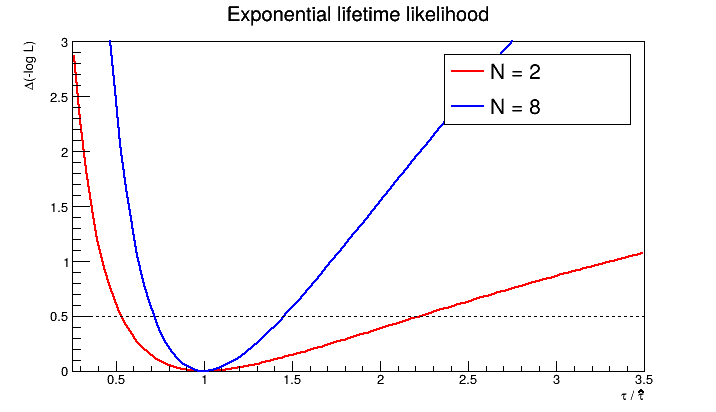

In [16]:
nll2 = ROOT.TF1("nll2", "2*(log(x)+1/x-1)", 0.25, 3.5)
nll8 = ROOT.TF1("nll8", "8*(log(x)+1/x-1)", 0.25, 3.5)
c = ROOT.TCanvas("c_nll", "Likelihood shape", 720, 440)
nll2.SetTitle("Exponential lifetime likelihood;#tau / #hat{#tau};#Delta(-log L)")
nll2.SetMinimum(0)
nll2.SetMaximum(3)
nll2.Draw()
nll8.SetLineColor(ROOT.kBlue)
nll8.Draw("same")
half = ROOT.TLine(0.25, 0.5, 3.5, 0.5)
half.SetLineStyle(2)
half.Draw()
nll_legend = ROOT.TLegend(0.62, 0.7, 0.88, 0.87)
nll_legend.AddEntry(nll2, "N = 2", "l")
nll_legend.AddEntry(nll8, "N = 8", "l")
nll_legend.Draw()
c.SaveAs("fit_figures/root-likelihood-errors.png")
display(Image(filename="fit_figures/root-likelihood-errors.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
auto nll2 = new TF1("nll2", "2*(log(x)+1/x-1)", 0.25, 3.5);
auto nll8 = new TF1("nll8", "8*(log(x)+1/x-1)", 0.25, 3.5);
c = new TCanvas("c_nll", "Likelihood shape", 720, 440);
nll2->SetTitle("Exponential lifetime likelihood;#tau / #hat{#tau};#Delta(-log L)");
nll2->SetMinimum(0);
nll2->SetMaximum(3);
nll2->Draw();
nll8->SetLineColor(kBlue);
nll8->Draw("same");
auto half = new TLine(0.25, 0.5, 3.5, 0.5);
half->SetLineStyle(2);
half->Draw();
auto nll_legend = new TLegend(0.62, 0.7, 0.88, 0.87);
nll_legend->AddEntry(nll2, "N = 2", "l");
nll_legend->AddEntry(nll8, "N = 8", "l");
nll_legend->Draw();
c->SaveAs("fit_figures/root-likelihood-errors.png");
```

</details>

两个参数的联合 confidence contour 不能沿用一参数阈值。在相同正则近似下，二维约 68.3% 的区域对应 $\Delta\chi^2=2.30$，或 $\Delta(-\log L)=1.15$；它也不是把两条一维误差区间拼成矩形。

下面用第 1 节直线拟合的协方差画出二维 68.3% 椭圆。倾斜来自截距与斜率的相关性。对于非线性或明显非 Gaussian 的 likelihood，协方差椭圆只是局部近似，需用 profile contour 检查。

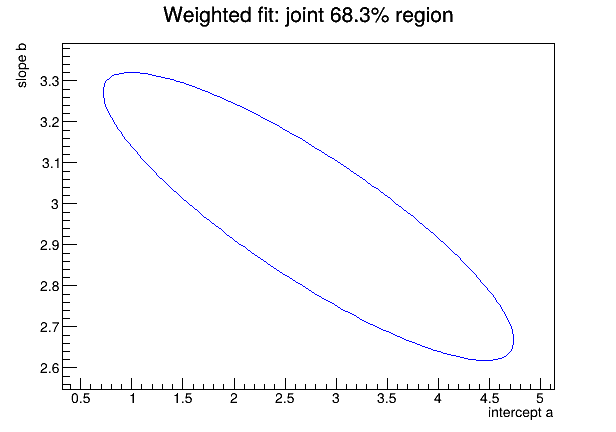

In [17]:
ellipse = ROOT.TGraph(201)
sa = math.sqrt(C[0][0])
scale = math.sqrt(2.30)
for i in range(201):
    angle = 2*math.pi*i/200
    da = scale*sa*math.cos(angle)
    db = scale*(C[0][1]/sa*math.cos(angle) + math.sqrt(C[1][1]-C[0][1]**2/C[0][0])*math.sin(angle))
    ellipse.SetPoint(i, line.GetParameter(0)+da, line.GetParameter(1)+db)
c = ROOT.TCanvas("c_contour", "Joint parameter region", 620, 460)
ellipse.SetTitle("Weighted fit: joint 68.3% region;intercept a;slope b")
ellipse.SetLineColor(ROOT.kBlue)
ellipse.Draw("AL")
c.SaveAs("fit_figures/root-parameter-contour.png")
display(Image(filename="fit_figures/root-parameter-contour.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
auto ellipse = new TGraph(201);
double sa = std::sqrt(C(0,0)), scale = std::sqrt(2.30);
for (int i = 0; i <= 200; ++i) {
    double angle = 2*TMath::Pi()*i/200;
    double da = scale*sa*std::cos(angle);
    double db = scale*(C(0,1)/sa*std::cos(angle) + std::sqrt(C(1,1)-C(0,1)*C(0,1)/C(0,0))*std::sin(angle));
    ellipse->SetPoint(i, line->GetParameter(0)+da, line->GetParameter(1)+db);
}
c = new TCanvas("c_contour", "Joint parameter region", 620, 460);
ellipse->SetTitle("Weighted fit: joint 68.3% region;intercept a;slope b");
ellipse->SetLineColor(kBlue);
ellipse->Draw("AL");
c->SaveAs("fit_figures/root-parameter-contour.png");
```

</details>

## 7. 初值、local minimum 与拟合稳定性

下面的目标函数只是 **local minimum 示意**。左右两个谷底说明：梯度方法即使在某处收敛，也不保证找到 global minimum。它不代表本教程某一次拟合的 likelihood。

Left minimum: p = -1.036, F = -0.305
Right minimum: p = 0.960, F = 0.294


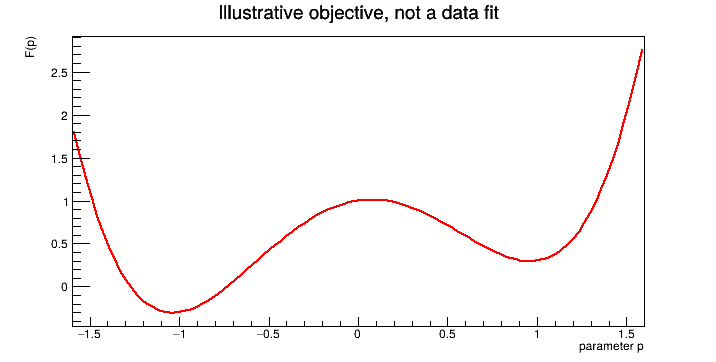

In [18]:
landscape = ROOT.TF1("landscape", "(x*x-1)*(x*x-1)+0.3*x", -1.6, 1.6)
left = landscape.GetMinimumX(-1.6, 0)
right = landscape.GetMinimumX(0, 1.6)
print(f"Left minimum: p = {left:.3f}, F = {landscape.Eval(left):.3f}")
print(f"Right minimum: p = {right:.3f}, F = {landscape.Eval(right):.3f}")
c = ROOT.TCanvas("c_minima", "Local minima illustration", 720, 390)
landscape.SetTitle("Illustrative objective, not a data fit;parameter p;F(p)")
landscape.Draw()
c.SaveAs("fit_figures/root-local-minima.png")
display(Image(filename="fit_figures/root-local-minima.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
auto landscape = new TF1("landscape", "(x*x-1)*(x*x-1)+0.3*x", -1.6, 1.6);
double left = landscape->GetMinimumX(-1.6, 0), right = landscape->GetMinimumX(0, 1.6);
std::cout << "Left minimum: p = " << left << ", F = " << landscape->Eval(left) << std::endl;
std::cout << "Right minimum: p = " << right << ", F = " << landscape->Eval(right) << std::endl;
c = new TCanvas("c_minima", "Local minima illustration", 720, 390);
landscape->SetTitle("Illustrative objective, not a data fit;parameter p;F(p)");
landscape->Draw();
c->SaveAs("fit_figures/root-local-minima.png");
```

</details>

实际拟合先检查三件事：

1. **状态与边界**：`int(result)==0` 表示 minimizer 报告成功；`CovMatrixStatus()==3` 表示协方差矩阵被认为准确。参数贴着限制、误差异常或状态非零都值得检查。
2. **模型与 residual**：总曲线是否描述了峰两侧？遗漏的相邻峰、错误的本底斜率或非 Gaussian 尾部，不能靠更严的收敛精度补救。
3. **合理的其他初值**：对同一数据和同一模型换几个初值，比较最终目标函数值和参数；若找到不同极小值，需要解决歧义再报告结果。

高阶多项式常出现很强的参数相关。先缩放、平移自变量，或考虑 Chebyshev 参数化，而不是立即提高多项式阶数。线性 least squares 中的“线性”指对**参数**线性，例如多项式也可用线性求解器；这与图上是否为直线不是一回事。

## 8. 继续使用这些工具

### 自定义函数与 Fit Panel

`TF1` 除了接受公式字符串，还可接受普通 Python/C++ 函数。只有公式难以清楚表示模型时才需要这样做；函数指针或 Python callable 的代码本身不能仅靠保存 `TF1` 就完整移植到另一环境。接口例子见 [TF1 官方参考](https://root.cern.ch/doc/master/classTF1.html)。

在本机交互 ROOT 会话中，可用 `histogram.FitPanel()`（C++ 为 `histogram->FitPanel()`）打开图形界面选择模型、范围和初值。它使用的统计方法与程序接口相同。确定分析方案后，把选择记录成代码，才能重现结果；batch notebook 不弹出这个窗口。

### 保存结果

实际分析可以把 histogram、模型与 `TFitResult` 写入 ROOT 文件。下面把本例联合拟合保存在独立的教程输出文件中；再次运行会更新该文件。

In [19]:
out = ROOT.TFile("root_fit_example.root", "RECREATE")
hp.Write("spectrum")
model.Write("model")
peak_result.Write("fit_result")
out.Close()
print("Saved: root_fit_example.root")

Saved: root_fit_example.root


<details><summary>ROOT C++ 对应代码</summary>

```cpp
TFile out("root_fit_example.root", "RECREATE");
hp->Write("spectrum");
model->Write("model");
peak_result->Write("fit_result");
out.Close();
std::cout << "Saved: root_fit_example.root" << std::endl;
```

</details>

需要归一化 PDF、逐事件 likelihood、多组分产额和 workspace 时，继续阅读 [RooFit：从 PDF 到组合模型与 likelihood](RooFit%20mini%20tutorial.html)。RooFit 与常规 ROOT Fit 是不同的模型组织接口，不是“一个用 ML、另一个用 least squares”。

## 资料与文件

- [下载本教程 notebook](ROOT_Fit_Tutorial.ipynb) · [ROOT C++ 完整宏](ROOT_Fit_Tutorial.C)。C++ 宏可用 `root -l -b -q ROOT_Fit_Tutorial.C` 运行。
- L. Moneta, [*Fitting and Parameter Estimation*](https://twiki.cern.ch/twiki/pub/Main/ROOTRioTutorial/ROOT_Rio2015_Fitting.pdf), ROOT Tutorial at UERJ, Rio de Janeiro (2015), pp. 6–38.
- ROOT Collaboration, [*Fitting histograms*](https://root.cern.ch/manual/fitting/), ROOT Manual；[TH1](https://root.cern.ch/doc/master/classTH1.html)、[TFitResult](https://root.cern.ch/doc/master/classTFitResult.html)、[TF1](https://root.cern.ch/doc/master/classTF1.html) reference documentation.
- S. Baker and R. D. Cousins, “Clarification of the use of chi-square and likelihood functions in fits to histograms,” *Nucl. Instrum. Methods* **221**, 437–442 (1984), [doi:10.1016/0167-5087(84)90016-4](https://doi.org/10.1016/0167-5087(84)90016-4).

本教程在 ROOT 6.40.02 中执行验证。代码只依赖 ROOT 与 notebook 的标准显示功能；图片保存在运行目录的 `fit_figures` 中。